### 🚢 Titanic Project - Data Analysis and Machine Learning

This project explores the Titanic dataset and builds a predictive model to estimate passenger survival.

#### Steps:
- Exploratory Data Analysis (EDA)
- Data cleaning
- Feature engineering
- Model training
- Model evaluation

### 📚 1. Import libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Machine Learning tools
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

### 📥 2. Load dataset

In [2]:
# Load dataset from seaborn
titanic = sns.load_dataset('titanic')

# Preview first rows
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
# General information about the dataset
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [4]:
# Statistical summary of numerical columns
titanic.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


### 🔎 3. Exploratory Data Analysis (EDA)

#### Survival distribution

C:\Users\f4212\AppData\Local\Temp\ipykernel_20600\1444557860.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=titanic, x='survived', palette=['#e5493c', '#3790cd'])


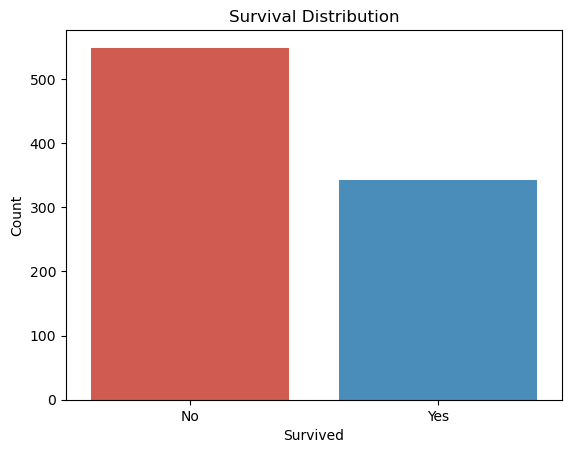

In [18]:
# Count of survivors vs non-survivors
sns.countplot(data=titanic, x='survived', palette=['#e5493c', '#3790cd'])
plt.title('Survival Distribution')
plt.xlabel('Survived')
plt.ylabel('Count')
plt.xticks([0, 1], ['No', 'Yes'])
plt.show()

Survival by gender

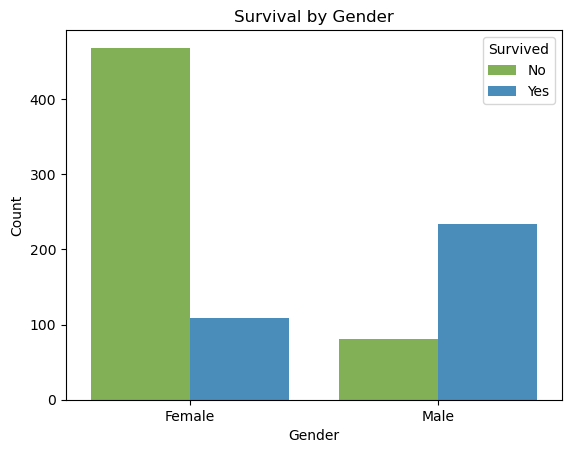

In [28]:
# Compare survival between male and female passengers
sns.countplot(data=titanic, x='sex', hue='survived', palette=['#80bf48', '#3790cd'])
plt.title('Survival by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.xticks([0, 1], ['Female', 'Male'])
plt.legend(title='Survived', labels=['No', 'Yes'])
plt.show()

Age distribution

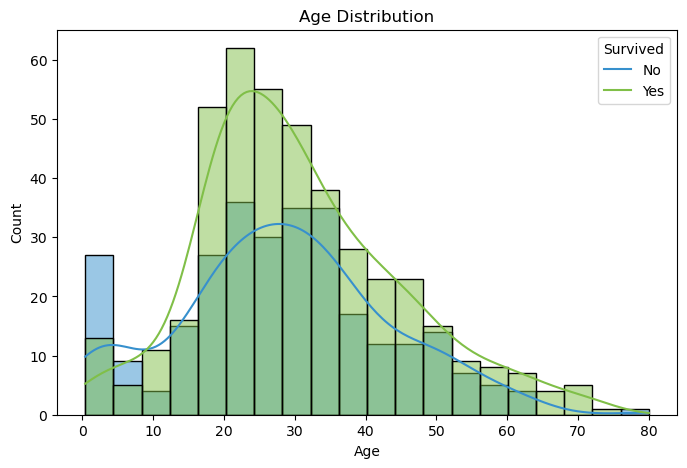

In [23]:
# Distribution of age with survival distinction
plt.figure(figsize=(8,5))
sns.histplot(data=titanic, x='age', hue='survived', bins=20, palette=['#80bf48', '#3790cd'],kde=True)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.legend(title='Survived', labels=['No', 'Yes'])
plt.show()

Passenger class vs survival

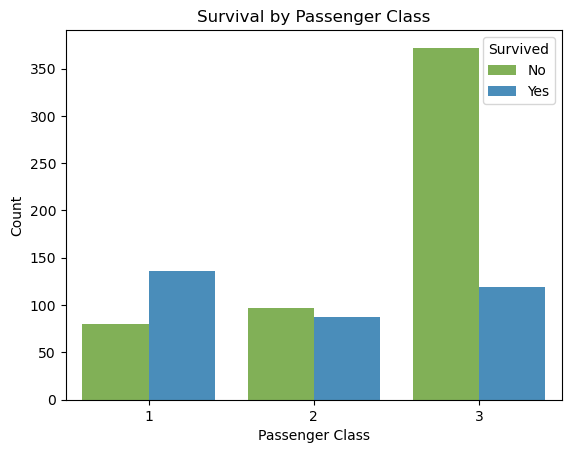

In [31]:
# Analyze survival based on passenger class
sns.countplot(data=titanic, x='pclass', hue='survived', palette=['#80bf48', '#3790cd'])
plt.title('Survival by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Count')
plt.legend(title='Survived', labels=['No', 'Yes'])
plt.show()

Correlation heatmap

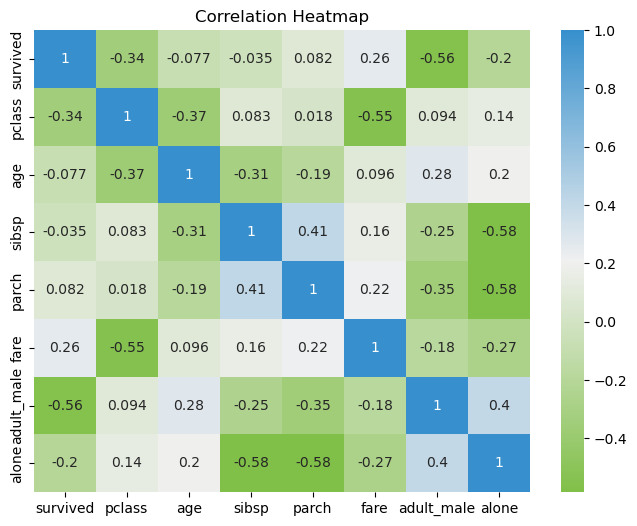

In [29]:
from matplotlib.colors import LinearSegmentedColormap

# Create custom colormap
custom_cmap = LinearSegmentedColormap.from_list(
    'custom_palette',
    ['#80bf48', '#f0f0f0', '#3790cd']
)

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(
    titanic.corr(numeric_only=True),
    annot=True,
    cmap=custom_cmap
)

plt.title('Correlation Heatmap')
plt.show()

### 🧹 4. Data Cleaning

Missing values

In [32]:
# Check missing values in each column
titanic.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

Fill missing age values

In [33]:
# Replace missing ages with the mean age
titanic['age'] = titanic['age'].fillna(titanic['age'].mean())

Drop irrelevant columns

In [34]:
# Convert categorical variables into numerical format
titanic['sex'] = titanic['sex'].map({'male': 0, 'female': 1})
titanic['embarked'] = titanic['embarked'].map({'C': 0, 'Q': 1, 'S': 2})

Encode categorical variables

In [35]:
# Convert categorical variables into numerical format
titanic['sex'] = titanic['sex'].map({'male': 0, 'female': 1})
titanic['embarked'] = titanic['embarked'].map({'C': 0, 'Q': 1, 'S': 2})

### 🧠 5. Feature Engineering

Family size

In [36]:
# Create a new feature representing family size
titanic['family_size'] = titanic['sibsp'] + titanic['parch'] + 1

Is alone

In [37]:
# Create a binary feature: 1 if passenger is alone, else 0
titanic['is_alone'] = (titanic['family_size'] == 1).astype(int)

### 🤖 6. Model Training

Define features and target

In [38]:
# Select features for the model
X = titanic[['pclass', 'sex', 'age', 'fare', 'family_size', 'is_alone']]

# Target variable
y = titanic['survived']

Train-test split

In [41]:
from sklearn.model_selection import train_test_split

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y 
)

Train model

In [43]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Build full ML pipeline
model = Pipeline(steps=[
    # Handle missing values
    ('imputer', SimpleImputer(strategy='mean')),

    # Feature scaling
    ('scaler', StandardScaler()),

    # Model
    ('classifier', LogisticRegression(max_iter=1000))
])

# Train pipeline (this fixes NaN issue automatically)
model.fit(X_train, y_train)

c:\Users\f4212\AppData\Local\anaconda3\Lib\site-packages\sklearn\impute\_base.py:635: UserWarning: Skipping features without any observed values: ['sex']. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(


Pipeline(steps=[('imputer', SimpleImputer()), ('scaler', StandardScaler()),
                ('classifier', LogisticRegression(max_iter=1000))])

In [44]:
X_train.isnull().sum()

pclass           0
sex            712
age              0
fare             0
family_size      0
is_alone         0
dtype: int64

### 📏 7. Model Evaluation

Predictions

In [45]:
# Generate predictions on test data
y_pred = model.predict(X_test)

c:\Users\f4212\AppData\Local\anaconda3\Lib\site-packages\sklearn\impute\_base.py:635: UserWarning: Skipping features without any observed values: ['sex']. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(


Accuracy

In [46]:
# Calculate accuracy score
accuracy_score(y_test, y_pred)

0.6871508379888268

Classification report

In [47]:
# Detailed performance metrics
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.71      0.84      0.77       110
           1       0.63      0.45      0.53        69

    accuracy                           0.69       179
   macro avg       0.67      0.64      0.65       179
weighted avg       0.68      0.69      0.67       179



Confusion matrix

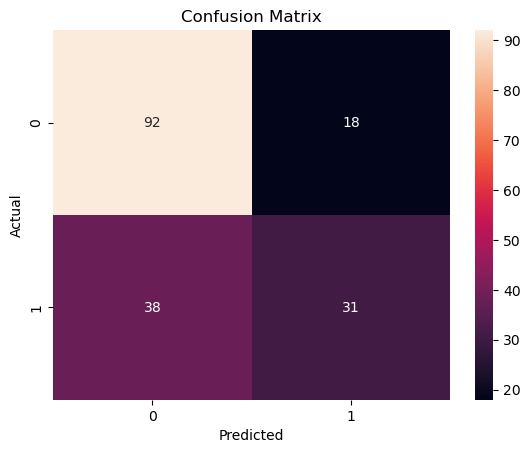

In [48]:
# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
sns.heatmap(cm, annot=True, fmt='d')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()